<Figure size 1400x1400 with 0 Axes>

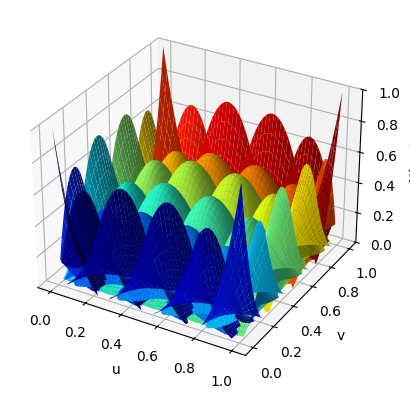

In [41]:
# do 2D version of simplified and GPU friendly code from end of 1_oned_basis.ipynb
import numpy as np
import matplotlib.pyplot as plt

# nxe = nye = 3
nxe = nye = 4
p = 2 # 2nd order elements
nnx = nxe + p
nny = nye + p
nelems = nxe * nye
nnodes = nnx * nny

N = 50
u, v = np.linspace(0.0, 1.0, N), np.linspace(0.0, 1.0, N)
U, V = np.meshgrid(u, v)

GLOB_BASES = np.zeros((nnodes, N, N))

elem_conn = []
for ielem in range(nelems):
    ixe = ielem % nxe; iye = ielem // nxe
    loc_conn = []
    for i2 in range((p+1)**2):
        i = i2 % (p+1); j = i2 // (p+1)
        gx = ixe + i
        gy = iye + j
        inode = nnx * gy + gx
        loc_conn += [inode]
    elem_conn += [loc_conn]
# print(F"{elem_conn=}")


x_knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
y_knots = [0.0]*(p+1) + [i/nye for i in range(1,nye)] + [1.0]*(p+1)

def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    # dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    # return N, dN
    return N

def get_1d_basis(xi, bndry_span):
    assert len(bndry_span) == 4
    B = quad_bernstein(xi)
    left_bndry = abs(bndry_span[0] - bndry_span[1]) < 1e-12
    right_bndry = abs(bndry_span[2] - bndry_span[3]) < 1e-12
    N = np.zeros_like(B)
    N[0] = (1.0 if left_bndry else 0.5) * B[0]
    N[2] = (1.0 if right_bndry else 0.5) * B[2]
    N[1] = B[1]
    N[1] += (0.0 if left_bndry else 0.5) * B[0]
    N[1] += (0.0 if right_bndry else 0.5) * B[2]
    return N

def get_2d_basis(XI, ETA, x_bndry_span, y_bndry_span):
    Nx = get_1d_basis(XI, x_bndry_span)
    Ny = get_1d_basis(ETA, y_bndry_span)
    # N2 = np.outer(Nx, Ny)
    N2 = np.zeros(((p+1)**2, XI.shape[0], XI.shape[1]))
    for i2 in range((p+1)**2):
        i = i2 % (p+1); j = i2 // (p+1)
        N2[i2] = Nx[i] * Ny[j]
    return N2


fig = plt.figure(figsize=(14,14))

nelems = nxe * nye
# for ielem in range(1): # DEBUG
for ielem in range(nelems):
    ixe = ielem % nxe; iye = ielem // nxe
    x_span = x_knots[(p+ixe):(p+ixe+2)]
    y_span = y_knots[(p+iye):(p+iye+2)]
    # print(f'{x_span=} {y_span=}')

    # compute normalized coordinates inside the 2x2 element span
    XI = (U - x_span[0]) / np.diff(x_span)[0]
    ETA = (V - y_span[0]) / np.diff(y_span)[0]

    # compute xi and eta masks
    XI_MASK = np.logical_and(U >= x_span[0], U <= x_span[1])
    ETA_MASK = np.logical_and(V >= y_span[0], V <= y_span[1])

    # get surrounding knots for boundary check
    x_bndry_span = x_knots[(p+ixe-1):(p+ixe+3)]
    y_bndry_span = y_knots[(p+iye-1):(p+iye+3)]

    # compute 2d bernstein basis
    N2 = get_2d_basis(XI, ETA, x_bndry_span, y_bndry_span)
    loc_conn = elem_conn[ielem]
    # print(f"{loc_conn=}")
    for loc_node, glob_node in enumerate(loc_conn):
        GLOB_BASES[glob_node] += N2[loc_node] * XI_MASK * ETA_MASK
    

# for inode in range(nnodes):
#     ix = inode % nnx; iy = inode // nnx

#     ax = fig.add_subplot(nnx, nny, inode+1, projection='3d')
#     ax.plot_surface(U, V, GLOB_BASES[inode])


# PLOT SURFACE BASIS FUNCTIONS!
# =====================
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, nnodes))  # one color per basis

# for inode in range(nnodes):
for inode in range(nnodes-1, -1, -1):
    Z = GLOB_BASES[inode]
    Z[Z < 0.01 * Z.max()] = np.nan

    ax.plot_surface(
        U, V, Z,
        color=colors[inode],   # solid color from jet
        # alpha=0.35,
        # alpha=0.6,
        # alpha=0.8,
        alpha=1.0,
        # linewidth=0,
        linewidth=0.5,
        antialiased=True
    )

ax.set_zlim(0.0, 1.0)
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_zlabel('N(u,v)')
plt.show()